##  Voting Regressor

---

### Core Idea

Different base models (regressors) are trained on the same dataset.

For a new input:
- Each model predicts a **numerical value**
- The final prediction is computed as the **average (mean)** of all predictions  

---

###  Intuition

Imagine asking multiple experts to estimate the price of a house:

- Expert 1 → ₹50 lakh  
- Expert 2 → ₹55 lakh  
- Expert 3 → ₹53 lakh  

Instead of trusting a single opinion, you take the **average**:

Final prediction → ₹52.67 lakh  

Even if one expert is slightly off, the average helps **balance errors** and gives a more reliable estimate.

👉 This is exactly how Voting Regressor works:
- Each model may make small errors  
- But averaging smooths out those errors  
- Result → more stable and accurate prediction  

---

###

[SkealearPage_votingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingRegressor.html)

## VotingClassifier Hyperparameters (Complete Overview)

```python
VotingClassifier(
    estimators,
    *,
    voting='hard',
    weights=None,
    n_jobs=None,
    flatten_transform=True,
    verbose=False
)

>  estimators

List of base models used in the ensemble.

- Format: list of tuples → (name, model)
- Example:
```python 
estimators = [
    ('lr', LogisticRegression()),
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True))
]
```


> voting (default = 'hard')

Determines how predictions are combined.

* 'hard' → Majority voting (class labels)
* 'soft' → Average of predicted probabilities

> weights (default = None)

Assigns importance to each model.

- List of numbers corresponding to each estimator
- Example:
```python 
weights = [2, 1, 2]
```

> n_jobs (default = None)

* Controls parallel processing.

- None → single core
- -1 → use all CPU cores

> flatten_transform (default = True)

* Controls output shape when using .transform().

* True → flattens output into 2D array
* False → keeps structured output

> verbose (default = False) - Controls logging during training.

- True → prints progress
- False → no output

# Example 

In [15]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [16]:
data = fetch_california_housing()

X = data.data
y = data.target

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
X.shape

(20640, 8)

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.ensemble import VotingRegressor

In [20]:
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=5)
svr = SVR()
knn = KNeighborsRegressor()

from sklearn.model_selection import cross_val_score

In [13]:
models = [
    ('Linear Regression', lr),
    ('Decision Tree', dt),
    ('SVR', svr),
    ('KNN', knn)
]

In [21]:
results = {}

for name, model in models:
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    results[name] = np.mean(scores)
    print(f"{name}: {np.round(np.mean(scores), 3)}")

Linear Regression: 0.553
Decision Tree: 0.461
SVR: -0.11
KNN: 0.002


### Voting Regressor

In [28]:
vr = VotingRegressor(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('svr', svr),
        ('knn', knn)
    ]
)

vr_score = cross_val_score(vr, X, y, cv=5, scoring='r2')
results['Voting Regressor'] = np.mean(vr_score)

print("Voting Regressor:", np.round(np.mean(vr_score), 3))

Voting Regressor: 0.424


In [29]:
results_df = pd.DataFrame(results, index=["R2 Score"]).T
results_df = results_df.sort_values(by="R2 Score", ascending=False)
results_df

,R2 Score
Linear Regression,0.553031
Decision Tree,0.461406
Voting Regressor,0.423840
Weighted Voting,0.272484
KNN,0.002335
SVR,-0.110119


<Figure size 640x480 with 0 Axes>

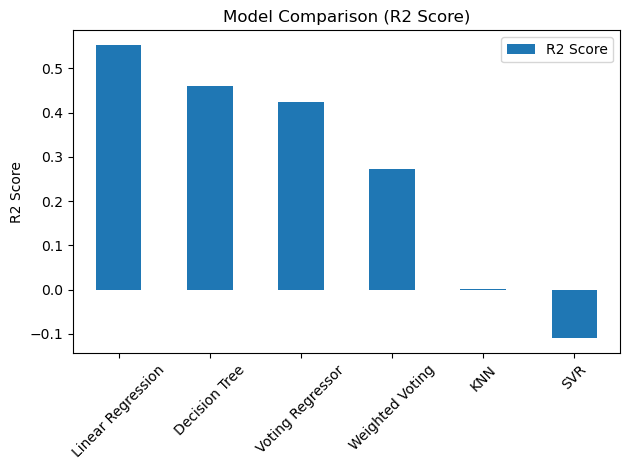

In [30]:
import matplotlib.pyplot as plt

plt.figure()
results_df.plot(kind='bar')
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
vr_weighted = VotingRegressor(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('svr', svr),
        ('knn', knn)
    ],
    weights=[1, 1, 3, 2]  # giving more importance to SVR & KNN
)

In [32]:
weighted_score = cross_val_score(vr_weighted, X, y, cv=5, scoring='r2')

print("Weighted Voting Regressor:",
      np.round(np.mean(weighted_score), 3))

Weighted Voting Regressor: 0.272


In [27]:
results['Weighted Voting'] = np.mean(weighted_score)

pd.DataFrame(results, index=["R2 Score"]).T.sort_values(
    by="R2 Score", ascending=False
)

,R2 Score
Linear Regression,0.553031
Decision Tree,0.461406
Voting Regressor,0.423874
Weighted Voting,0.272484
KNN,0.002335
SVR,-0.110119
